# Task 3 — Consultas Athena e Dashboard Interativo

Fonte: esquema estrela da Task 2 (Parquet no S3 / catálogo Glue).

**Pré-requisitos** (execute antes de abrir este notebook):
```
python 1_setup_catalog.py   # provisiona catálogo Glue e roda o crawler
python 2_validate_athena.py # valida as consultas
```

## 4.1 — Configuração

In [1]:
import json
import os
from pathlib import Path

from dotenv import load_dotenv
import boto3
import awswrangler as wr
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

HERE = Path().resolve()
load_dotenv(HERE / ".env")

# Lê configurações geradas pelo Terraform / 1_setup_catalog.py
_info = json.loads((HERE / "catalog_info.json").read_text())

GLUE_DATABASE = _info["glue_database"]
ATHENA_OUTPUT = _info["athena_output"]

boto_session = boto3.Session(
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    aws_session_token=os.getenv("AWS_SESSION_TOKEN"),
    region_name=os.getenv("AWS_REGION", "us-east-1"),
)

print(f"Database Glue : {GLUE_DATABASE}")
print(f"Saída Athena  : {ATHENA_OUTPUT}")

Database Glue : classicmodels_analytics
Saída Athena  : s3://classicmodels-datalake-grupo3-henrique/athena-results/


## 4.2 — Consulta exploratória em `dim_products`

In [2]:
sql_products = """
SELECT
    product_id,
    product_name,
    product_line,
    product_vendor
FROM dim_products
LIMIT 20
"""

df_products = wr.athena.read_sql_query(
    sql=sql_products,
    database=GLUE_DATABASE,
    s3_output=ATHENA_OUTPUT,
    boto3_session=boto_session,
)

print(f"dim_products — {len(df_products)} linhas")
display(df_products)

dim_products — 20 linhas


,product_id,product_name,product_line,product_vendor
0,S18_1662,1980s Black Hawk Helicopter,Planes,Red Start Diecast
1,S18_2581,P-51-D Mustang,Planes,Gearbox Collectibles
2,S18_3259,Collectable Wooden Train,Trains,Carousel DieCast Legends
3,S32_3207,1950's Chicago Surface Lines Streetcar,Trains,Gearbox Collectibles
4,S50_1514,1962 City of Detroit Streetcar,Trains,Classic Metal Creations
5,S700_1691,American Airlines: B767-300,Planes,Min Lin Diecast
6,S700_2466,America West Airlines B757-200,Planes,Motor City Art Classics
7,S700_2834,ATA: B757-300,Planes,Highway 66 Mini Classics
8,S700_3167,F/A 18 Hornet 1/72,Planes,Motor City Art Classics
9,S700_4002,American Airlines: MD-11S,Planes,Second Gear Diecast


## 4.3 — Vendas totais por país

Vendas por país — 10 países


,country,total_sales
0,USA,3273280.05
1,Spain,1099389.09
2,France,1007374.02
3,Australia,562582.59
4,New Zealand,476847.01
5,UK,436947.44
6,Italy,360616.81
7,Finland,295149.35
8,Singapore,263997.78
9,Denmark,218994.92


C:\Users\julia\AppData\Local\Temp\ipykernel_17664\756119770.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_country, x="total_sales", y="country", ax=ax, palette="Blues_r")


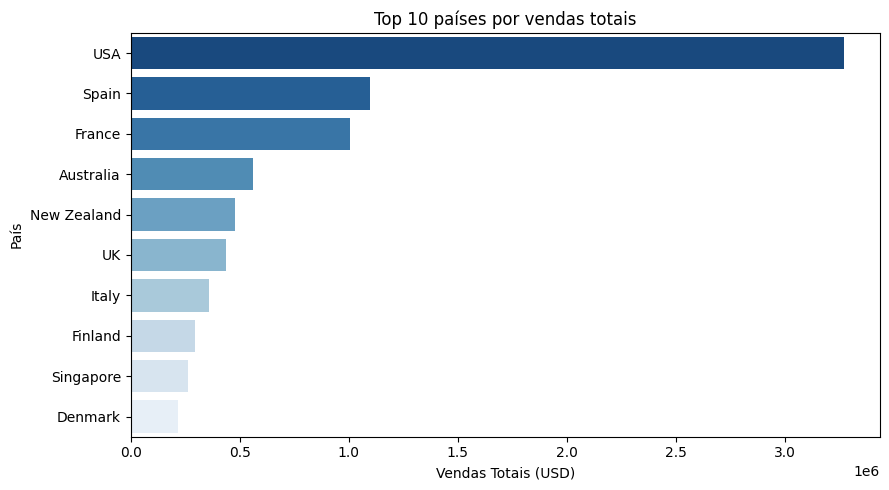

In [3]:
sql_country_sales = """
SELECT
    dim_countries.country,
    SUM(fact_orders.sales_amount) AS total_sales
FROM fact_orders
JOIN dim_countries ON fact_orders.country_key = dim_countries.country_key
GROUP BY dim_countries.country
ORDER BY total_sales DESC
LIMIT 10
"""

df_country = wr.athena.read_sql_query(
    sql=sql_country_sales,
    database=GLUE_DATABASE,
    s3_output=ATHENA_OUTPUT,
    boto3_session=boto_session,
)

print(f"Vendas por país — {len(df_country)} países")
display(df_country)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df_country, x="total_sales", y="country", ax=ax, palette="Blues_r")
ax.set_xlabel("Vendas Totais (USD)")
ax.set_ylabel("País")
ax.set_title("Top 10 países por vendas totais")
plt.tight_layout()
plt.show()

## 4.4 — Detalhamento por data, linha de produto, produto e país

In [4]:
sql_detail = """
SELECT
    dim_dates.full_date,
    dim_products.product_line,
    dim_products.product_name,
    dim_countries.country,
    SUM(fact_orders.sales_amount) AS total_sales
FROM fact_orders
JOIN dim_products  ON fact_orders.product_id      = dim_products.product_id
JOIN dim_countries ON fact_orders.country_key     = dim_countries.country_key
JOIN dim_dates     ON fact_orders.order_date_key  = dim_dates.date_key
GROUP BY
    dim_dates.full_date,
    dim_products.product_line,
    dim_products.product_name,
    dim_countries.country
"""

df_detail = wr.athena.read_sql_query(
    sql=sql_detail,
    database=GLUE_DATABASE,
    s3_output=ATHENA_OUTPUT,
    boto3_session=boto_session,
)

# Converte tipos para garantir operações numéricas e de data no dashboard
df_detail["full_date"] = pd.to_datetime(df_detail["full_date"])
df_detail["total_sales"] = pd.to_numeric(df_detail["total_sales"], errors="coerce")

print(f"Base analítica — {len(df_detail):,} linhas")
print(f"Período        — {df_detail['full_date'].min().date()} a {df_detail['full_date'].max().date()}")
print(f"Países         — {df_detail['country'].nunique()}")
print(f"Linhas produto — {df_detail['product_line'].nunique()}")
display(df_detail.head())

Base analítica — 2,996 linhas
Período        — 2003-01-06 a 2005-05-31
Países         — 22
Linhas produto — 7


,full_date,product_line,product_name,country,total_sales
0,2003-01-06,Vintage Cars,1911 Ford Town Car,USA,2754.50
1,2003-04-01,Classic Cars,1958 Chevy Corvette Limited Edition,France,687.36
2,2003-04-01,Trucks and Buses,1926 Ford Fire Engine,France,2406.60
3,2003-04-16,Classic Cars,1969 Corvair Monza,Singapore,6366.58
4,2003-04-16,Classic Cars,2001 Ferrari Enzo,Singapore,6445.89


## 4.5 — Dashboard Interativo

Filtros: intervalo de datas, país, linha de produto e Top N.  
Gráfico de barras horizontal — Top N produtos por `sales_amount`.

In [5]:
date_min = df_detail["full_date"].min().date()
date_max = df_detail["full_date"].max().date()

w_start = widgets.DatePicker(
    description="Início:", value=date_min,
    style={"description_width": "60px"}, layout=widgets.Layout(width="220px"),
)
w_end = widgets.DatePicker(
    description="Fim:", value=date_max,
    style={"description_width": "60px"}, layout=widgets.Layout(width="220px"),
)
w_country = widgets.Dropdown(
    options=["Todos"] + sorted(df_detail["country"].unique().tolist()),
    value="Todos", description="País:",
    style={"description_width": "60px"}, layout=widgets.Layout(width="260px"),
)
w_line = widgets.Dropdown(
    options=["Todos"] + sorted(df_detail["product_line"].unique().tolist()),
    value="Todos", description="Linha:",
    style={"description_width": "60px"}, layout=widgets.Layout(width="300px"),
)
w_topn = widgets.IntSlider(
    min=1, max=10, value=5, description="Top N:",
    style={"description_width": "60px"}, layout=widgets.Layout(width="300px"),
)

out = widgets.Output()


def update(_=None):
    with out:
        clear_output(wait=True)

        mask = (
            (df_detail["full_date"].dt.date >= w_start.value)
            & (df_detail["full_date"].dt.date <= w_end.value)
        )
        if w_country.value != "Todos":
            mask &= df_detail["country"] == w_country.value
        if w_line.value != "Todos":
            mask &= df_detail["product_line"] == w_line.value

        filtered = df_detail[mask]
        if filtered.empty:
            print("Nenhum dado para os filtros selecionados.")
            return

        top = (
            filtered.groupby("product_name")["total_sales"]
            .sum()
            .nlargest(w_topn.value)
            .reset_index()
            .sort_values("total_sales")
        )

        fig, ax = plt.subplots(figsize=(10, max(4, w_topn.value * 0.65)))
        sns.barplot(data=top, x="total_sales", y="product_name", ax=ax, palette="viridis")
        ax.set_xlabel("Vendas Totais (USD)")
        ax.set_ylabel("Produto")
        ax.set_title(
            f"Top {w_topn.value} produtos — {w_country.value} | {w_line.value}"
        )
        plt.tight_layout()
        plt.show()


for w in [w_start, w_end, w_country, w_line, w_topn]:
    w.observe(update, names="value")

display(widgets.VBox([
    widgets.HBox([w_start, w_end]),
    widgets.HBox([w_country, w_line, w_topn]),
    out,
]))
update()